In [101]:
import numpy as np
import matplotlib.pyplot as plt

In [103]:
#构建随机数集用于回归

np.random.seed(0)
n_samples = 100
x_12 = np.random.randn(n_samples,2)
y = -3*x_12[:,0] + 2*x_12[:,1] + 1 + 0.25*np.random.randn(n_samples)

In [105]:
#构造设计矩阵
#注意第一个参数就是全部的需要拼接的数组
    #这里第一个参数叫做可迭代对象(可迭代容器),直接传入这个,不分散在其他参数上
X = np.column_stack((np.ones_like(y),x_12))

In [107]:
b = np.linalg.inv(X.T@X) @ X.T @ y
b

array([ 0.98714722, -2.97238377,  1.98649073])

In [109]:
x1_grid,x2_grid = np.meshgrid(np.linspace(-3,3,10),
                              np.linspace(-3,3,10))
X_grid = np.column_stack((x1_grid.flatten(),x2_grid.flatten()))

In [111]:
X_grid = np.column_stack((np.ones_like(X_grid[:,[0]]),X_grid))
y_pred = X_grid @ b
#将2D列向量变回到对应点的矩阵形式
y_pred = y_pred.reshape(x1_grid.shape)

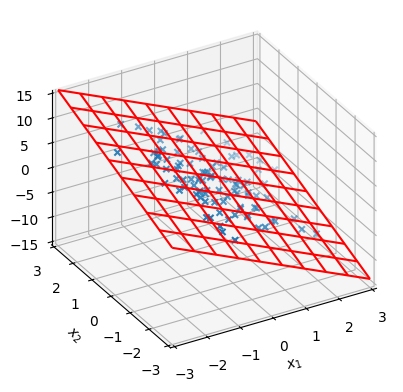

In [113]:
fig = plt.figure()
#111表示一行一列 第一个子图
ax = fig.add_subplot(111,projection = '3d')
ax.scatter(x_12[:,0],x_12[:,1],y,marker = 'x')

#前三个参数这里对应坐标矩阵,三个参数XYZ必须都是2D的
    #如果XYZ都是1D一般表示画线,2D才表示画网
    #2D之所以能够画网格是因为传入的是网格.会按照网格的行方向和列方向(对应XY给的点和Z)画两组线构成网格
ax.plot_wireframe(x1_grid,x2_grid,y_pred,color = 'r')

#$会使字符渲染成数学字体
#数学表达式会使得绘图程序进行特殊处理,如使数学表达式按照轴方向绘制,使其符合科学绘图规范
ax.set_xlabel('$x_1$');ax.set_ylabel('$x_2$')
ax.set_zlabel('y')
#带不带[]效果相同
    #因为会提前判断自动解包选择合适的解析方式
ax.set_xlim([-3,3]);ax.set_ylim(-3,3)
ax.set_zlim([-15,15])
ax.set_proj_type('ortho');ax.view_init(azim = -120,elev = 30)

In [122]:
import numpy as np
import matplotlib.pyplot as plt
#只用import只能导入包或者模块,这里from+import导入的是类,类不能用import直接导入
    #'.'语法只能用于包或模块的路径,不能用于内部的类,函数,变量这种内部对象
from sklearn.linear_model import LinearRegression

In [128]:
np.random.seed(0)
n_samples = 100
x_12 = np.random.randn(n_samples,2)
y = -3*x_12[:,0] + 2*x_12[:,1] + 1 + 0.25*np.random.randn(n_samples)

In [138]:
LR = LinearRegression()
y_predicted = LR.fit(x_12,y)

In [140]:
slope = LR.coef_ #斜率,coef是coefficient(系数)的意思
intercept = LR.intercept_

In [142]:
slope

array([-2.97238377,  1.98649073])

In [144]:
intercept

0.9871472187028183

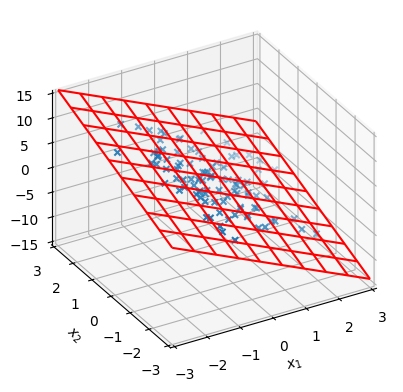

In [164]:
fig = plt.figure()
ax = fig.add_subplot(111,projection = '3d')

ax.scatter(x_12[:,0],x_12[:,1],y,marker = 'x')

x1_grid,x2_grid = np.meshgrid(np.linspace(-3,3,10),
                              np.linspace(-3,3,10))
#.flatten返回值是副本没有改变原来的x1_grid,原地改变需用到reshape
    #flatten返回一个扁平的复制品,但是是否真的修改需要看方法实际运算,这里没有修改原数组而是修改副本并返回
X_grid = np.column_stack((x1_grid.flatten(),x2_grid.flatten()))

y_pred = LR.predict(X_grid)
y_pred = y_pred.reshape(x1_grid.shape)

ax.plot_wireframe(x1_grid,x2_grid,y_pred,color = 'r')

ax.set_xlabel('$x_1$');ax.set_ylabel('$x_2$')
ax.set_zlabel('y')
ax.set_xlim(-3,3);ax.set_ylim(-3,3)
ax.set_zlim(-15,15)
ax.set_proj_type('ortho');ax.view_init(azim = -120,elev = 30)